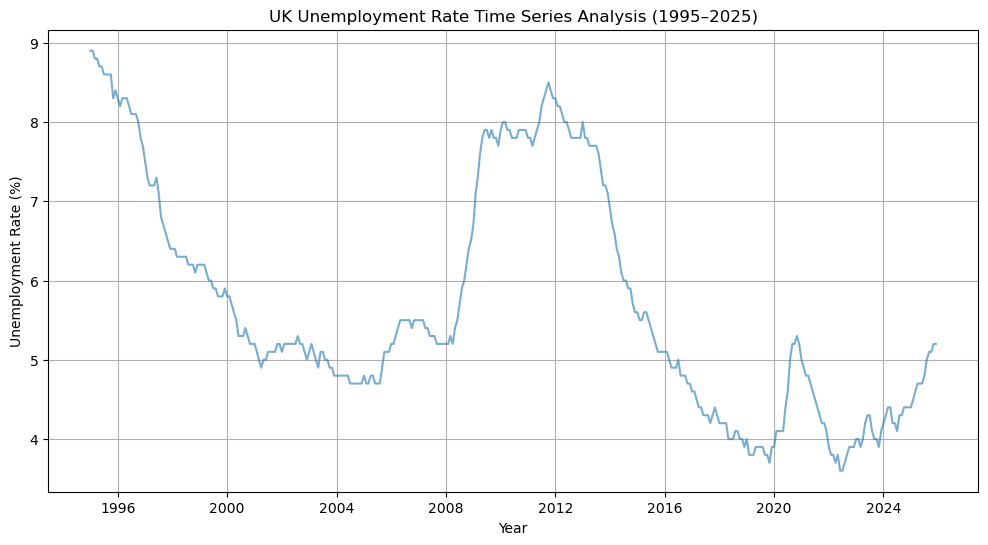

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel(r"C:\Users\sharm\Downloads\Unemployment_1995-2025.xlsx")
df = df.rename(columns={
    "Yr_Month": "Date",
    "Unemployment rate (aged 16 and over, seasonally adjusted): %": "Unemployment_Rate"
})
df["Date"] = pd.to_datetime(df["Date"], format="%Y %b")
df = df.sort_values("Date")
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Unemployment_Rate"], label="Monthly Unemployment Rate", alpha=0.6)
plt.title("UK Unemployment Rate Time Series Analysis (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

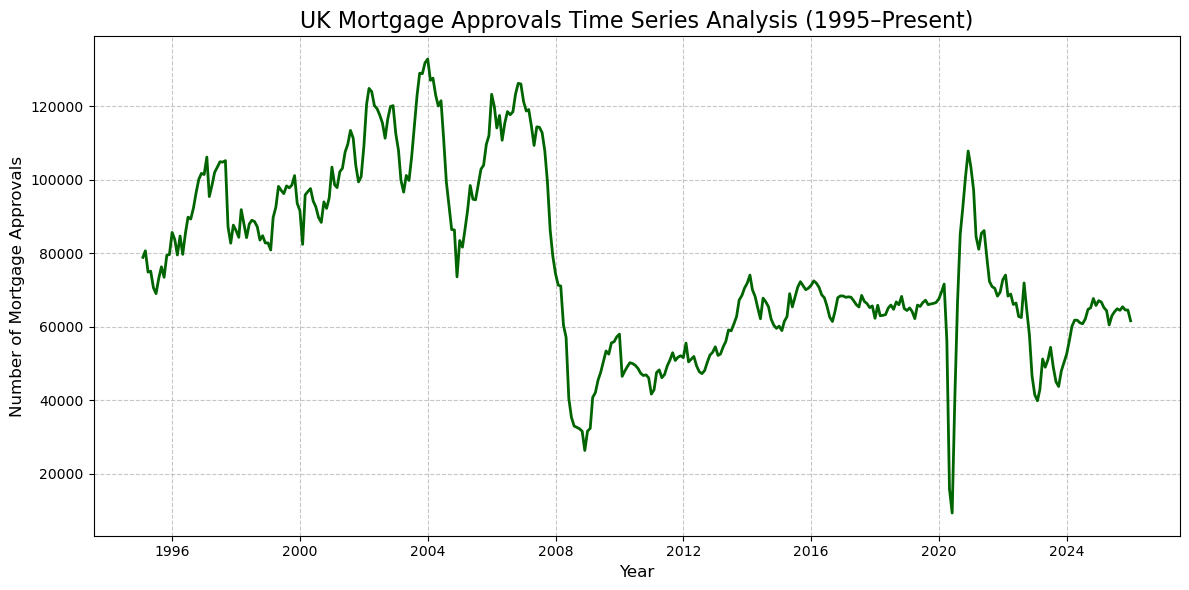

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\sharm\Downloads\Mortgage Approvals.csv")

# Rename the columns
df.rename(columns={
    "Monthly number of total sterling approvals for house purchase to individuals seasonally adjusted              [a] [b] [c]             LPMVTVX": "Mortgage_Approvals"
}, inplace=True)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

# Sort by date
df.sort_values("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Mortgage_Approvals"],
         color="darkgreen",
         linewidth=2)

plt.title("UK Mortgage Approvals Time Series Analysis (1995–Present)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Mortgage Approvals", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

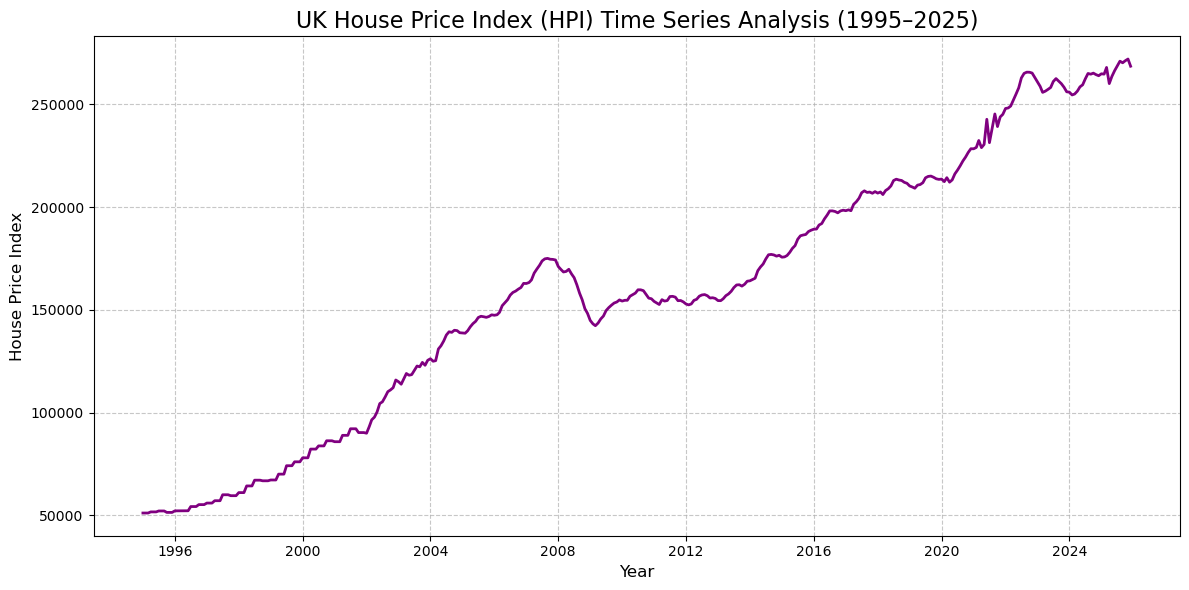

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\sharm\Downloads\UK_HPI_1995_2025.csv")

# Rename the columns
df.rename(columns={
    "Yr_Month": "Date",
    "Average price All property types": "HPI"
}, inplace=True)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%Y %b")

# Sort by date
df.sort_values("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["HPI"],
         color="purple",
         linewidth=2)

plt.title("UK House Price Index (HPI) Time Series Analysis (1995–2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("House Price Index", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

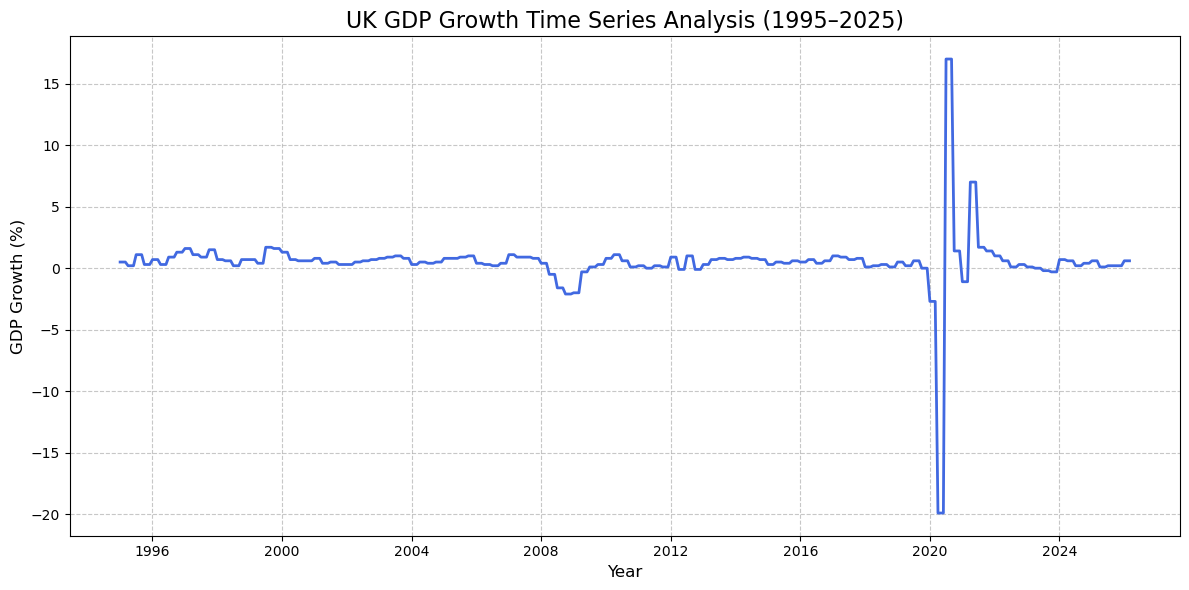

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\sharm\Downloads\GDP_.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")

# Sort by date
df.sort_values("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["GDP"],
         color="royalblue",
         linewidth=2)

plt.title("UK GDP Growth Time Series Analysis (1995–2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("GDP Growth (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

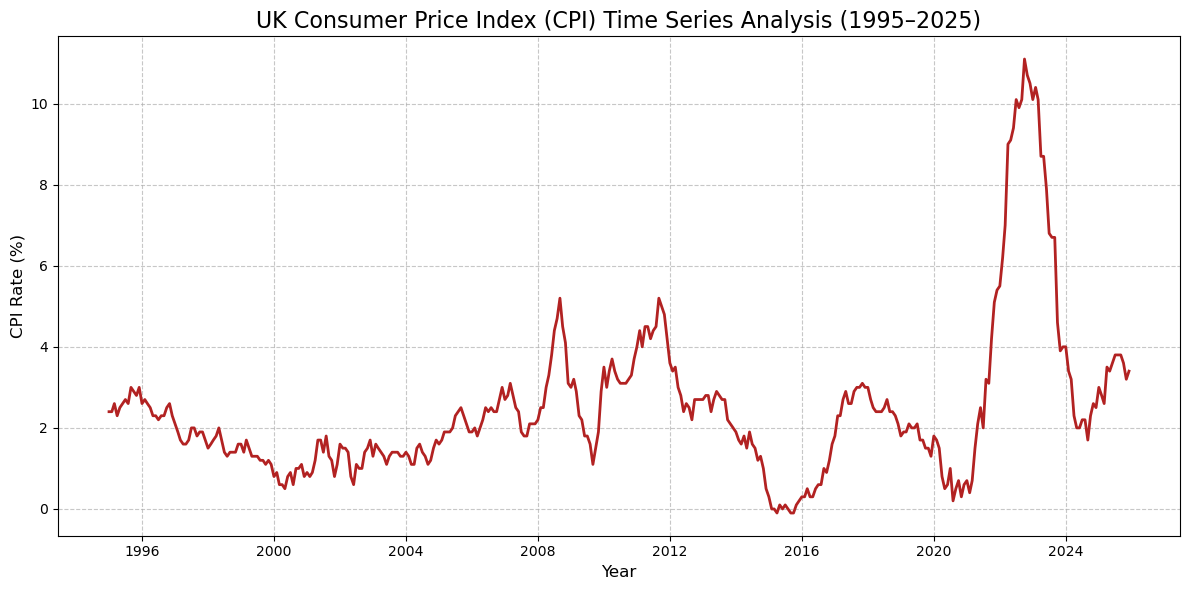

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_excel(r"C:\Users\sharm\Downloads\CPI_1995-2025.xlsx")

# Rename columns
df.rename(columns={
    "Yr_Month": "Date",
    "CPI  Rate": "CPI_Rate"
}, inplace=True)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%Y %b")

# Sort by date
df.sort_values("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["CPI_Rate"],
         color="firebrick",
         linewidth=2)

plt.title("UK Consumer Price Index (CPI) Time Series Analysis (1995–2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CPI Rate (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

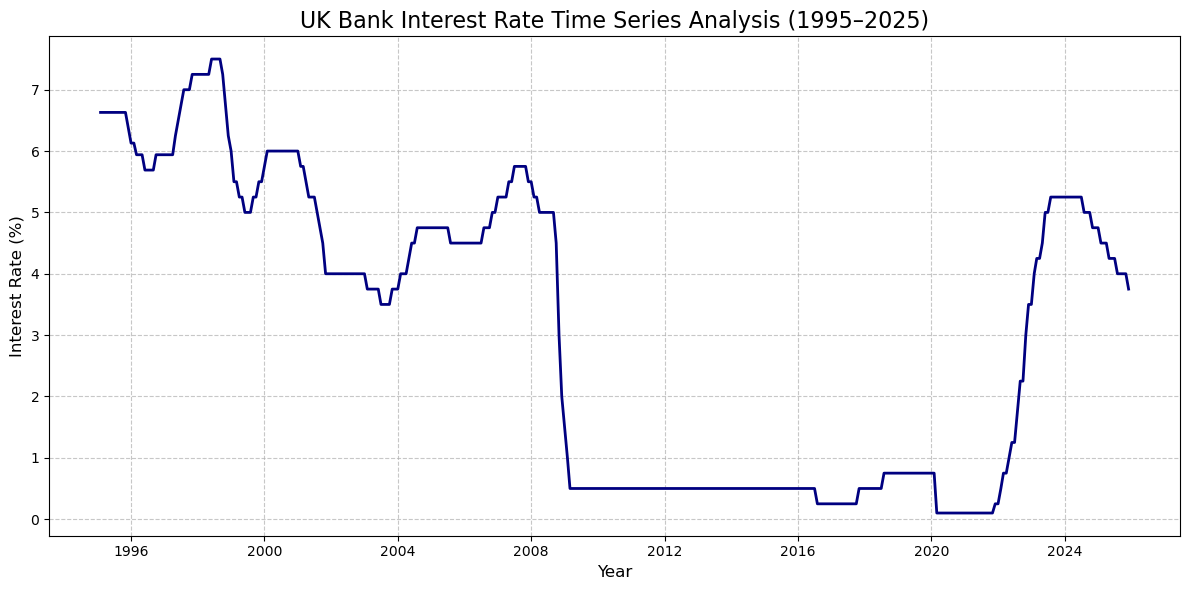

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\sharm\Downloads\INTEREST_RATE_CLEAN.csv")

# Rename columns
df.rename(columns={
    "Rate": "Interest_Rate"
}, inplace=True)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

# Sort by date
df.sort_values("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Interest_Rate"],
         color="navy",
         linewidth=2)

plt.title("UK Bank Interest Rate Time Series Analysis (1995–2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Interest Rate (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

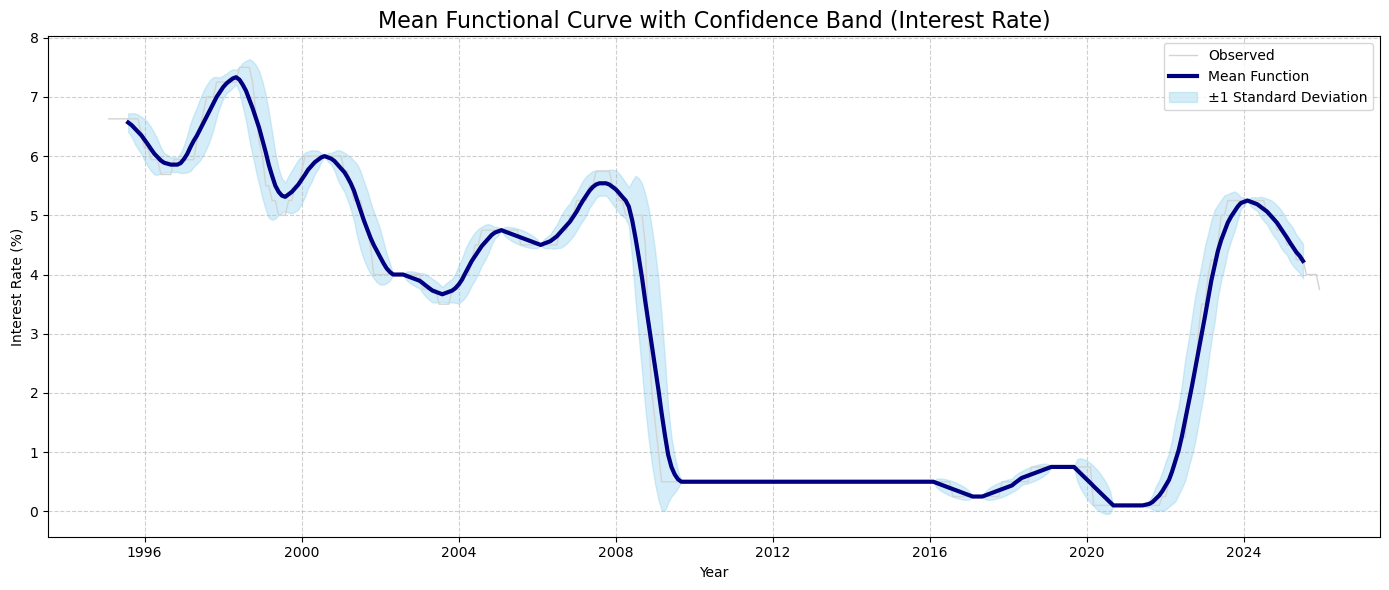

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\sharm\Downloads\INTEREST_RATE_CLEAN.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")
df = df.sort_values("Date")

# Rolling Mean (12 months)
df["Mean"] = df["Rate"].rolling(window=12, center=True).mean()

# Rolling Standard Deviation
df["SD"] = df["Rate"].rolling(window=12, center=True).std()

# Plot
plt.figure(figsize=(14,6))

# Original observations
plt.plot(df["Date"], df["Rate"],
         color="lightgray",
         linewidth=1,
         label="Observed")

# Mean functional curve
plt.plot(df["Date"], df["Mean"],
         color="navy",
         linewidth=3,
         label="Mean Function")

# Confidence band
plt.fill_between(
    df["Date"],
    df["Mean"] - df["SD"],
    df["Mean"] + df["SD"],
    color="skyblue",
    alpha=0.35,
    label="±1 Standard Deviation"
)

plt.title("Mean Functional Curve with Confidence Band (Interest Rate)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


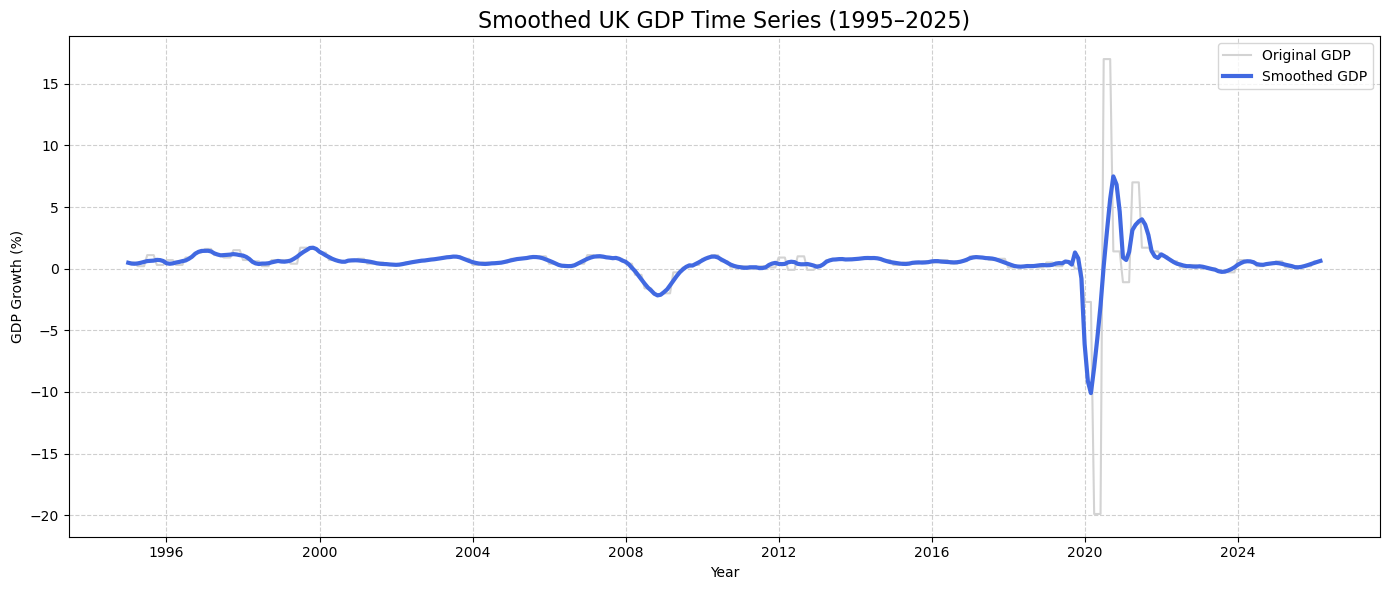

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Load GDP data
df = pd.read_csv(r"C:\Users\sharm\Downloads\GDP_.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")

# Sort
df = df.sort_values("Date")

# Smooth GDP
df["GDP_Smoothed"] = savgol_filter(df["GDP"], window_length=13, polyorder=3)

# Plot
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["GDP"],
         color="lightgray",
         linewidth=1.5,
         label="Original GDP")

plt.plot(df["Date"], df["GDP_Smoothed"],
         color="royalblue",
         linewidth=3,
         label="Smoothed GDP")

plt.title("Smoothed UK GDP Time Series (1995–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Explained Variance Ratio:
[0.39021349 0.21679641]


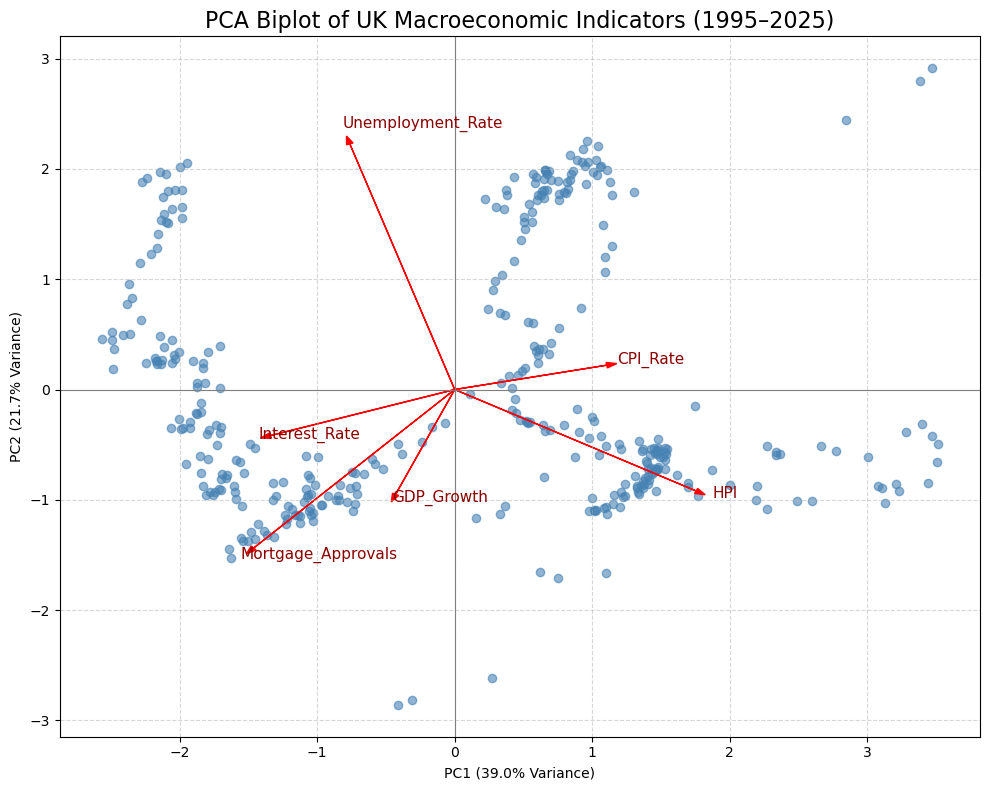

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_excel(r"C:\Users\sharm\Downloads\PROJECT_DATASET (1).xlsx")

# Rename columns
df.rename(columns={
    "Yr_Month": "Date",
    "Bank rate": "Interest_Rate",
    "Mortgage": "Mortgage_Approvals",
    "CPI  Rate": "CPI_Rate",
    "GDP_growth": "GDP_Growth",
    "House price index All property types": "HPI",
    "Unemployment rate (aged 16 and over, seasonally adjusted): %": "Unemployment_Rate"
}, inplace=True)

# Select variables
features = [
    "Interest_Rate",
    "Mortgage_Approvals",
    "CPI_Rate",
    "GDP_Growth",
    "HPI",
    "Unemployment_Rate"
]

# Convert to numeric
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove missing values
df = df.dropna(subset=features)

# Standardize variables
X = StandardScaler().fit_transform(df[features])

# PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10,8))

# PCA scores
plt.scatter(scores[:,0], scores[:,1],
            alpha=0.6,
            color="steelblue")

# Variable loadings
loadings = pca.components_.T

for i, feature in enumerate(features):
    plt.arrow(0, 0,
              loadings[i,0]*3,
              loadings[i,1]*3,
              color='red',
              head_width=0.05)

    plt.text(loadings[i,0]*3.2,
             loadings[i,1]*3.2,
             feature,
             color='darkred',
             fontsize=11)

plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")

plt.title("PCA Biplot of UK Macroeconomic Indicators (1995–2025)", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

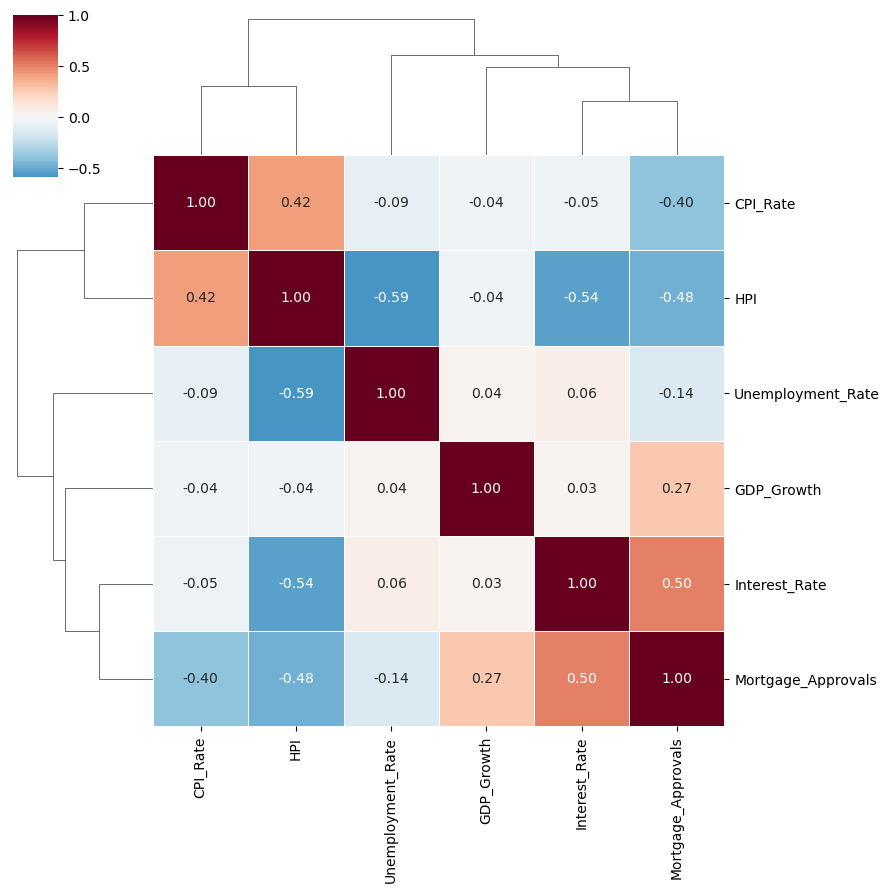

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel(r"C:\Users\sharm\Downloads\PROJECT_DATASET (1).xlsx")

# Rename columns
df.rename(columns={
    "Bank rate": "Interest_Rate",
    "Mortgage": "Mortgage_Approvals",
    "CPI  Rate": "CPI_Rate",
    "GDP_growth": "GDP_Growth",
    "House price index All property types": "HPI",
    "Unemployment rate (aged 16 and over, seasonally adjusted): %": "Unemployment_Rate"
}, inplace=True)

features = [
    "Interest_Rate",
    "Mortgage_Approvals",
    "CPI_Rate",
    "GDP_Growth",
    "HPI",
    "Unemployment_Rate"
]

df[features] = df[features].apply(pd.to_numeric, errors="coerce")

# Clustered heatmap
sns.clustermap(
    df[features].corr(),
    annot=True,
    cmap="RdBu_r",
    center=0,
    figsize=(9,9),
    linewidths=0.5,
    fmt=".2f"
)

plt.show()